In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ['TORCH_USE_CUDA_DSA'] = '1'
from torch import optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np 
import random
import torchvision 
import torch.nn.functional as functional

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


In [3]:
# Setting uniform seed

In [4]:
torch.manual_seed(64)
torch.cuda.manual_seed(64)
random.seed(42)

In [5]:
# Set Hyper Parameters

In [6]:
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 3e-4
LION_LEARNING_RATE= 1e-4
PATCH_SIZE = 4
NUM_CLASSES=200 # for CIFAR
IMAGE_SIZE = 64
CHANNELS = 3
EMBEDDING_DIM = 192
NUM_HEADS = 3
DEPTH = 8 # Number of Transformer Encoder Blocks
MLP_DIM = 512
DROPOUT_RATE=0.1

In [7]:
#Patch Embedding , Create patches and return Tensor of Dimansion :  128 X 65 X 128 : 128 images 65 tokens(patches + CLS) per image, 
#128d per token (128d vector per patch)

class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embedding_dim):
        super().__init__()
        self.patch_size = patch_size
       # IMPORTANT : Use Convolution 2d as Projection Layer as its more efficient than a Linear Layer . The paper actually Mentions a Linear Layer . 
       # kernel and stride are assigned to patch size as we want patches and not overlaps  
        self.projection = nn.Conv2d(in_channels = in_channels, out_channels = embedding_dim, kernel_size = patch_size , stride=patch_size)
       # For square images number of patches is (image size/patch size) ^2         
        num_patches = (image_size//patch_size)**2
        #The CLS token (classification token) in Vision Transformers is a special learnable parameter that serves as a placeholder
        #for aggregating global information from all image patches for classification tasks
        self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim)) # Random to begin with

                                      
    def forward(self, tensor: torch.Tensor):
            # Tensor is 128 X 3 X 32 X 32 ( 3 , 32, 32 is the image 32X32 with 3 channels) 
            batch_size = tensor.size(0) # Get Batch Size 
            projected_tensor = self.projection(tensor)  # Each patch becomes 128d feature vector Tensor is now : 128*128*8*8
            flattened_tensor = projected_tensor.flatten(2) # flatten 128*128*8*8 to 128*128*64
            transposed_tensor = flattened_tensor.transpose(1,2) # swap to : 128 *64*128 converts tensor to format (batch_size, sequence_length, embedding_dim) by swapping dims: 
            cls_token = self.cls_token.expand(batch_size, -1, -1) # cls_token is replicated to all 128 images in the batch 
            tensor_with_cls_token = torch.cat((cls_token, transposed_tensor), dim=1)   # CLS Token in position 0 , Position 1 to 64 image patches
            return tensor_with_cls_token # 128 X 65 X 128 : 128 images 65 tokens per image ( CLS token + 64 Patches), 128d representation of each token   
    

In [8]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, dropout_rate):
        super().__init__()
        self.fc1 = nn.Linear(in_features=in_features, out_features=hidden_features)
        self.fc2 = nn.Linear(in_features=hidden_features, out_features=in_features)
        self.dropout = nn.Dropout(dropout_rate)
    def forward(self, tensor): # EXPAND ACTIVATE PROJECT BACK , Maintains original Dimensions 
        tensor = self.fc1(tensor)  # Tensor is  128 X 65 X 128 , output is 128 X 65 X 512
        tensor = self.dropout(functional.gelu(tensor)) # Input & output is 128 X 65 X 512 , Activation Function : Gaussian Error Linear Unit
        tensor = self.dropout(self.fc2(tensor)) # input is 128 X 65 X 512 and output is 128 X 65 X 128
        return tensor
        

In [9]:
class ConvTransformerEncoder(nn.Module): 
    def __init__(self, embedding_dim, num_heads, mlp_dim, dropout_rate):
        super().__init__()
        self.norm1 = nn.LayerNorm(embedding_dim) # Mean 0 STD 1 
        # Strides for Convolution as per CVT Paper
        self.q_stride = 1
        self.k_stride = 2
        self.v_stride = 2
        self.kernel_size = 3
        self.in_channels = self.out_channels = embedding_dim
        self.groups = embedding_dim

        # Convolutions for Q K and V . groups is the MOST important thing , as groups  = embedding dimension , 
        # convolution runs on each channel with a 3X3 Kernel, capturing information about neighbors . 
        # Thats why we dont need Positional Embedding , and this is called Local Inductive Bias . 
        
        self.conv_q = nn.Conv2d(in_channels=self.in_channels, 
                                out_channels=self.out_channels, 
                                kernel_size=self.kernel_size,
                                padding = 1,
                                stride = self.q_stride,
                                groups = self.groups
                                )

        self.conv_k = nn.Conv2d(in_channels=self.in_channels, 
                                out_channels=self.out_channels, 
                                kernel_size=self.kernel_size,
                                padding = 1,
                                stride = self.k_stride,
                                groups = self.groups
                                )

        self.conv_v = nn.Conv2d(in_channels=self.in_channels, 
                                out_channels=self.out_channels, 
                                kernel_size=self.kernel_size,
                                padding = 1,
                                stride = self.v_stride,
                                groups = self.groups
                                )
        
        # Each head will process embed_dim/num_heads dimensions so embed_dim%num_heads should be 0 . 
        #batch_first=True: Input shape is (batch, seq, features) → (128, 65, 128)
        # Each head processes: 384 / 12 = 32 dimensions for 8 heads
        # Internally reshaped to: (128, 65, 8, 16) (batch seq heads head_dim) ; Output Concatenated Back to 128 X 65 X 128
        # Pre Norm Architecture ( Norm before addign to Multi Head Attenstion as per VIT Paper)  stabilizes gradients during training, enables training of deeper networks
        #often converges faster than the original "post-norm" design from Attention paper
        self.multiHeadAttn = nn.MultiheadAttention(embed_dim=embedding_dim, num_heads=num_heads, dropout=dropout_rate, batch_first=True)
        # normalizing before each major operation prevents gradient Explosion and Vanishing Gradients during Back Prop
        self.norm2 = nn.LayerNorm(embedding_dim) # Mean 0 STD 1 
        #  position-wise feed-forward network MLP : Applier Non Linear Transformation on the token generated from MHA 
        # MLP applies the same transformation independently to each of the 65 tokens ( 64 Patches + CLS Token ) 
        self.mlp = MLP(embedding_dim, mlp_dim, dropout_rate)

    def forward(self, tensor : torch.Tensor ):
      # Remove CLS Token from pensor and perform convolutions on patches only 
        cls_token = tensor[:, 0:1, :]  # [128, 1, 384]
        patches = tensor[:, 1:, :]     # [128, 64, 384]
        batch_size, num_patches, embed_dim = patches.shape
        #print("Input Tensor Shape ", tensor.shape)
        #print("batch Size ", batch_size)
        #print("num patches", num_patches)
        #print("Embedding Dim ", embed_dim)
        height = width = np.sqrt(num_patches).astype(np.int64)
        # Normalize - Layer Norm
        patches = self.norm1(patches)
        #print("Normalized Tensor Shape ", patches.shape)
        patches_transposed = patches.transpose(1,2)
        # Convert to Spacial Format for Convolution
        #print("Transposed Tensor Shape", patches_transposed.shape)
        patches_spacial = patches_transposed.reshape(batch_size, embed_dim, height, width)
        
        q = self.conv_q(patches_spacial)
        k = self.conv_k(patches_spacial)
        v = self.conv_v(patches_spacial)
        # back to sequence format for attention
        q = q.flatten(2).transpose(1, 2)
        k = k.flatten(2).transpose(1, 2)
        v = v.flatten(2).transpose(1, 2)
        q_with_cls = torch.cat([cls_token, q], dim=1)
        k_with_cls = torch.cat([cls_token, k], dim=1)
        v_with_cls = torch.cat([cls_token, v], dim=1)
        #print("q after adding cls token", q_with_cls.shape)
        # q k v for Mutlihead Self Attention come from convolutions unlike VIT
        attn_output, attn_weights = self.multiHeadAttn(query = q_with_cls , key= k_with_cls , value = v_with_cls) 
        tensor = tensor + attn_output # Residual Conenction : Add Original Input to the output from Multi Head Attention 
        tensor = tensor + self.mlp(self.norm2(tensor))
        return tensor # Shape 128 X 65 X 128 maintained

In [10]:
class VisionTransformer(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, num_classes, embedding_dim, depth, num_heads, mlp_dims, dropout_rate):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, embedding_dim)
        self.encoder = nn.Sequential(
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate),
            ConvTransformerEncoder(embedding_dim, num_heads, mlp_dims, dropout_rate)
            
        )
        self.norm = nn.LayerNorm(embedding_dim)
        # logits=W⋅x+b , Output is logits of num classes size vector
        self.classification_head = nn.Linear(in_features = embedding_dim, out_features= num_classes) # Linear Classification Head 

    def forward(self, tensor):
        tensor_with_Pos_Embed = self.patch_embed(tensor)
        encoder_output = self.encoder(tensor_with_Pos_Embed)
        normed_encoder_output = self.norm(encoder_output)
        cls_token = normed_encoder_output[:, 0] # Token at position 0 is the CLS TOKEN with Dimension 128 X 128 
        # Coz CLS Token was PREPENDED at position 0 
        return self.classification_head(cls_token) # Output Shape is 128 X 10  ( 10 Classes) 

In [11]:
# Init the Vision transformer Model

model = VisionTransformer(IMAGE_SIZE, PATCH_SIZE,CHANNELS,200, EMBEDDING_DIM, DEPTH, NUM_HEADS, MLP_DIM, DROPOUT_RATE ).to(device)

In [12]:
model

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (projection): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): ConvTransformerEncoder(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (conv_q): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=192)
      (conv_k): Conv2d(192, 192, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=192)
      (conv_v): Conv2d(192, 192, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=192)
      (multiHeadAttn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=192, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=192, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (1): ConvTransformerEn

In [13]:
# IMAGE TRANSFORM and dataset prep
! pip install tinyimagenet

In [14]:
from tinyimagenet import TinyImageNet
import logging
logging.basicConfig(level=logging.INFO)
from pathlib import Path

train_transformer = transforms.Compose([
transforms.Resize(256),    
transforms.CenterCrop(224),
transforms.RandomHorizontalFlip(),
transforms.RandAugment(num_ops=2, magnitude=9),
transforms.ToTensor(),
transforms.Normalize(mean=TinyImageNet.mean,  std=TinyImageNet.std)    
])
dataset_path="~/.torchvision/tinyimagenet/"
train_dataset = TinyImageNet(Path(dataset_path),split="train",transform=train_transformer,imagenet_idx=False)

In [15]:
train_dataset

Dataset TinyImageNet
    Number of datapoints: 100000
    Root location: C:\Users\nawas\.torchvision\tinyimagenet\tiny-imagenet-200\train
    StandardTransform
Transform: Compose(
               Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224))
               RandomHorizontalFlip(p=0.5)
               RandAugment(num_ops=2, magnitude=9, num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Target transform: <function TinyImageNet.__init__.<locals>.<lambda> at 0x000001978D652B60>

In [16]:
# Load Testing Data 

val_transformer = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize(mean=TinyImageNet.mean,  std=TinyImageNet.std)
])

test_transformer = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize(mean=TinyImageNet.mean,  std=TinyImageNet.std)
])

val_dataset = TinyImageNet(Path(dataset_path),split="val",transform=val_transformer,imagenet_idx=False)
test_dataset = TinyImageNet(Path(dataset_path),split="test",transform=test_transformer,imagenet_idx=False)

In [17]:
val_dataset

Dataset TinyImageNet
    Number of datapoints: 10000
    Root location: C:\Users\nawas\.torchvision\tinyimagenet\tiny-imagenet-200\val
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Target transform: <function TinyImageNet.__init__.<locals>.<lambda> at 0x000001978DB43600>

In [18]:
test_dataset

Dataset TinyImageNet
    Number of datapoints: 10000
    Root location: C:\Users\nawas\.torchvision\tinyimagenet\tiny-imagenet-200\test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Target transform: <function TinyImageNet.__init__.<locals>.<lambda> at 0x000001978DB439C0>

In [19]:
#DataLoaders

dataloader_train = DataLoader(train_dataset, batch_size=24, shuffle=True, pin_memory=True)
dataloader_val = DataLoader(val_dataset, batch_size=24, shuffle=False, pin_memory=True)
dataloader_test = DataLoader(test_dataset, batch_size=24, shuffle=False, pin_memory=True)

print(f"TRAIN DATALOADER : {len(dataloader_train)} batches")
print(f"VAL DATALOADER : {len(dataloader_val)} batches")
print(f"TEST DATALOADER : {len(dataloader_test)} batches")

TRAIN DATALOADER : 4167 batches
VAL DATALOADER : 417 batches
TEST DATALOADER : 417 batches


In [20]:


# Training
from torch.amp import autocast, GradScaler
def train(model, loader : DataLoader, optimizer, loss_function):
    model.train()
    #scaler = GradScaler()
   # if not hasattr(train, 'label_map'):
   #     label_map = {}
   #     all_labels = []
   #    for _, labels in loader:
   #         all_labels.extend(labels.tolist()) # Collect all Labels 
   #     sorted_unique_labels = sorted(set(all_labels)) # sort them 
        #print(sorted_unique_labels)
        # MAP the Bloody Imagenet weird numbered labels to 0 to 199 and get the trainign working as a result .
   #     for new_label, old_label in enumerate(sorted_unique_labels):
   #         label_map[old_label] = new_label
    #    train.label_map = label_map        
   # print("TRAINING LABEL MAP : ",train.label_map)    
    
    correct, total_loss = 0, 0  
    for i, (img_batch, labels) in enumerate(loader):
        if i%100 == 0:
          print(f"Batch {i}")
        #print(f"  Min label: {labels.min().item()}")
        #print(f"  Max label: {labels.max().item()}")
        #print(f"  Label dtype: {labels.dtype}")
        #print(f"  Sample labels: {labels[:10].tolist()}")
        #remapped_list = []
        
        labels = labels.to(device)
        img_batch = img_batch.to(device)
        #labels = labels.to(device)
        optimizer.zero_grad()
        output = model(img_batch)
        loss = loss_function(output, labels)
        loss.backward()
        optimizer.step()
        total_loss+= loss.item() * img_batch.size(0)
        correct+= (output.argmax(1)==labels).sum().item()
    return total_loss/len(loader.dataset) , correct/len(loader.dataset)  

In [21]:
# Evaluation
def evaluate_model(model, loader : DataLoader):
    model.eval()
    correct = 0
        
    with torch.inference_mode():
        for img_batch, labels in loader:
            labels = labels.to(device) 
            img_batch = img_batch.to(device)    
            output = model(img_batch)
            predictions = output.argmax(dim=1)
            correct+= (predictions==labels).sum().item()
        return correct/len(loader.dataset)      

In [22]:
from tqdm.auto import tqdm

c:\ProgramData\anaconda3\envs\LLM_3_12_12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

torch.cuda.empty_cache()
import gc
gc.collect()

train_accuracies, test_accuracies = [], []
EPOCHS=10
# Cross Entropy Loss and AdamW Optimizer 
loss_function = nn.CrossEntropyLoss()
optimizer = optim.AdamW(params=model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.999), weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, dataloader_train, optimizer, loss_function)
    test_acc = evaluate_model(model, dataloader_val)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch : {epoch+1} of {EPOCHS}, Train Loss : {train_loss:.4f} , Train Accuracy : {train_acc:.4f}, Test Accuracy : {test_acc:.4f}")
    scheduler.step() 

Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 600
Batch 700
Batch 800
Batch 900
Batch 1000
Batch 1100
Batch 1200
Batch 1300
Batch 1400
Batch 1500
Batch 1600
Batch 1700
Batch 1800
Batch 1900
Batch 2000
Batch 2100
Batch 2200
Batch 2300
Batch 2400
Batch 2500
Batch 2600
Batch 2700
Batch 2800
Batch 2900
Batch 3000
Batch 3100
Batch 3200
Batch 3300
Batch 3400
Batch 3500
Batch 3600
Batch 3700
Batch 3800
Batch 3900
Batch 4000
Batch 4100
Epoch : 1 of 10, Train Loss : 5.1139 , Train Accuracy : 0.0214, Test Accuracy : 0.0192
Batch 0
Batch 100
Batch 200
Batch 300
Batch 400
Batch 500
Batch 600
Batch 700
Batch 800
Batch 900
Batch 1000
Batch 1100
Batch 1200
Batch 1300
Batch 1400
Batch 1500
Batch 1600
Batch 1700
Batch 1800
Batch 1900
Batch 2000
Batch 2100
Batch 2200
Batch 2300
Batch 2400
Batch 2500
Batch 2600
Batch 2700
Batch 2800
Batch 2900
Batch 3000
Batch 3100
Batch 3200
Batch 3300
Batch 3400
Batch 3500
Batch 3600
Batch 3700
Batch 3800
Batch 3900
Batch 4000
Batch 4100
Epoch : 2 of 

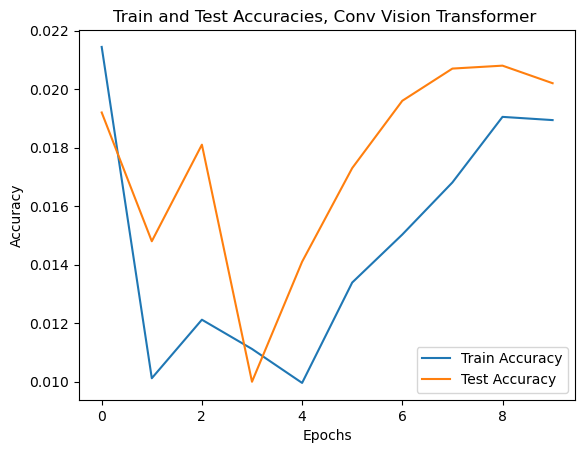

In [24]:
plt.plot(train_accuracies, label = "Train Accuracy")
plt.plot(test_accuracies, label = "Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Train and Test Accuracies, Conv Vision Transformer ")
plt.savefig("ConvVisionTransformer-12Layers-TinyImageNet.png",  dpi=300)
plt.show()

In [25]:
torch.save(model, 'ConvVisionTransformer_12Layers_TinyImageNet_AdamW.pth')

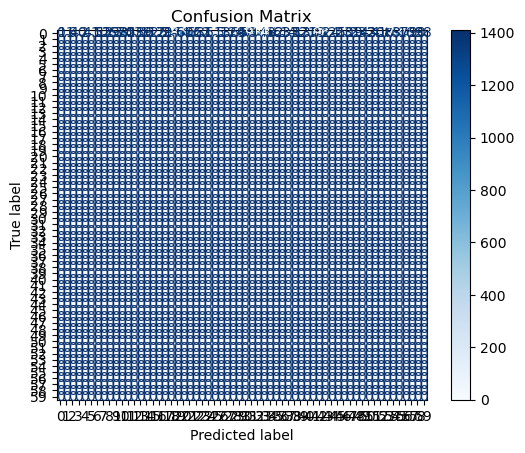

Test Accuracy: 0.02%
Precision: 0.00
Recall:    0.00
F1 Score:  0.00


c:\ProgramData\anaconda3\envs\LLM_3_12_12\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\envs\LLM_3_12_12\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('ConvVisionTransformer_12Layers_TinyImageNet_AdamW.pth', weights_only=False)

def test_model(model, loader : DataLoader):
    model.eval()
    correct = 0
    all_labels = []
    all_predictions = []
    with torch.inference_mode():
        for img_batch, labels in loader:
            labels = labels.to(device)
            img_batch = img_batch.to(device)
            output = model(img_batch)
            predictions = output.argmax(dim=1)
            correct+= (predictions==labels).sum().item()
            all_labels.extend(labels.to("cpu").numpy())
            all_predictions.extend(predictions.to("cpu").numpy())
        return correct/len(loader.dataset), all_labels, all_predictions   

test_accuracy, all_labels, all_predictions = test_model(model, dataloader_test)
        
cm = confusion_matrix(all_labels, all_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig("ConvVisionTransformerTinyImageNetConfusionMatrix.png",  dpi=300)
plt.show()
print(f"Test Accuracy: {test_acc:.2f}%")
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
f1 = f1_score(all_labels, all_predictions, average='weighted')
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")
 